# DFP Toy Experiments

This notebook runs particle-based Drifting Field Policy toy experiments on a checkerboard and a 2D swiss roll. The drift computation mirrors the simplified `toy_mean_drift.py` form: `targets = [gen, pos]`, self-mask on generated points, `exp(-dist / temp)`, and normalization by `sqrt(row_sum * col_sum)`.


In [47]:
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import jax
from jax.scipy.special import logsumexp

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax


plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [48]:
import torch
from functools import partial


DISTANCE_EPS = 1e-8
TEMP_EPS = 1e-6
SELF_DISTANCE_MASK = 1e2


def pairwise_distance(x, y, action_mask=None):
    # [B, N, D] x [B, M, D] -> [B, N, M]
    diff = x[:, :, None, :] - y[:, None, :, :]
    if action_mask is not None:
        diff = diff * action_mask[:, None, None, :]
    sq_dist = jnp.sum(jnp.square(diff), axis=-1)
    return jnp.sqrt(jnp.clip(sq_dist, a_min=DISTANCE_EPS))


@jax.jit
def drifting_field(query_actions, positive_actions, temp=0.05, drift_type="sinkhorn"):
    # Same structure as toy_mean_drift.py: targets = [gen, pos].
    action_dim = query_actions.shape[-1]
    temp = jnp.maximum(temp, TEMP_EPS)
    num_gen = query_actions.shape[-2]
    targets = jnp.concatenate([query_actions, positive_actions], axis=-2)

    dist = pairwise_distance(query_actions, targets)
    # Scale by dist and masking
    # action_scale = dist.mean()
    # scaled_action_unit = jnp.clip(action_scale / jnp.sqrt(action_dim), a_min=1e-3)
    # query_actions = query_actions / scaled_action_unit
    # positive_actions = positive_actions / scaled_action_unit
    # dist = dist / scaled_action_unit

    
    # drifting calculation
    log_kernel = -dist / temp
    if drift_type=="sinkhorn":
        log_kernel_pos = log_kernel[..., num_gen:]
        log_kernel_neg = log_kernel[..., :num_gen]
        if log_kernel_neg.shape[-2] == log_kernel_neg.shape[-1]:
            eye = jnp.eye(log_kernel_neg.shape[-2], dtype=log_kernel_neg.dtype)
            # log_kernel_neg = log_kernel_neg + eye[None, :, :] * -jnp.inf
            # log_kernel_neg = log_kernel_neg.at[jnp.arange(log_kernel_neg.shape[-2]), jnp.arange(log_kernel_neg.shape[-1])].set(-jnp.inf)
        for _ in range(30):
            log_kernel_pos = log_kernel_pos - logsumexp(log_kernel_pos, axis=-1, keepdims=True)
            log_kernel_pos = log_kernel_pos - logsumexp(log_kernel_pos, axis=-2, keepdims=True)
            log_kernel_neg = log_kernel_neg - logsumexp(log_kernel_neg, axis=-1, keepdims=True)
            log_kernel_neg = log_kernel_neg - logsumexp(log_kernel_neg, axis=-2, keepdims=True)
        normalized_pos = jnp.exp(log_kernel_pos) /  (jnp.exp(log_kernel_pos).sum(axis=-1, keepdims=True) + 1e-6)
        normalized_neg = jnp.exp(log_kernel_neg) / (jnp.exp(log_kernel_neg).sum(axis=-1, keepdims=True) + 1e-6)
    else:
        eye = jnp.eye(num_gen, dtype=dist.dtype)
        block_mask = jnp.pad(eye, ((0, 0), (0, positive_actions.shape[-2])))
        dist = dist + block_mask[None, :, :] * SELF_DISTANCE_MASK
        row_norm = jax.nn.softmax(log_kernel, axis=-1)
        col_norm = jax.nn.softmax(log_kernel, axis=-2)
        normalized_kernel = jnp.sqrt(jnp.clip(row_norm * col_norm, a_min=1e-6))

        normalized_neg = normalized_kernel[..., :num_gen]
        normalized_pos = normalized_kernel[..., num_gen:]

    pos_mass = normalized_pos.sum(axis=-1, keepdims=True)
    neg_mass = normalized_neg.sum(axis=-1, keepdims=True)
    pos_coeff = normalized_pos #* neg_mass
    neg_coeff = normalized_neg #* pos_mass
    total_coeff = pos_coeff.sum(axis=-1, keepdims=True) - neg_coeff.sum(axis=-1, keepdims=True)


    pos_v = pos_coeff @ positive_actions
    neg_v = neg_coeff @ query_actions
    drift = pos_v - neg_v #- total_coeff * query_actions
    f_norm = (drift ** 2).mean() # [B]


    force_scale = jnp.sqrt(jnp.clip(f_norm, a_min=1e-8))
    return drift, {
        "temp": temp,
        "drift_norm": force_scale,
        "pos_weight_mean": pos_coeff.mean(),
        "pos_weight_max": pos_coeff.max(),
        "pos_weight_min": pos_coeff.min(),
        "neg_weight_mean": neg_coeff.mean(),
        "neg_weight_max": neg_coeff.max(),
        "neg_weight_min": neg_coeff.min(),
        "pos_dist_mean": dist[..., num_gen:].mean(),
        "neg_dist_mean": dist[..., :num_gen].mean(),
        "pos_mass_mean": pos_mass.mean(),
        "neg_mass_mean": neg_mass.mean(),
    }

@jax.jit
def compute_drift(gen, pos, temp=0.05):
    drift, drift_info = drifting_field(gen[None, ...], pos[None, ...], temp=temp)
    return drift[0], drift_info

@jax.jit
def drift_loss(query_actions, positive_actions, temp=0.05):
    drift, drift_info = drifting_field(query_actions, positive_actions, temp=temp)
    drift_targets = jax.lax.stop_gradient(query_actions + drift)
    squared_error = jnp.square(query_actions - drift_targets)
    loss = jnp.mean(squared_error)
    return loss, drift_info


In [49]:
import jax.numpy as jnp
jnp.exp(-jnp.inf)


Array(0., dtype=float32, weak_type=True)

drift test shape (100, 2)
drift info: {'drift_norm': 0.08622448891401291, 'neg_dist_mean': 0.8736226558685303, 'neg_mass_mean': 0.9999990463256836, 'neg_weight_max': 0.31023743748664856, 'neg_weight_mean': 0.009999987669289112, 'neg_weight_min': 0.0007424054201692343, 'pos_dist_mean': 0.9096105098724365, 'pos_mass_mean': 0.9999998807907104, 'pos_weight_max': 0.015299201011657715, 'pos_weight_mean': 0.0019999993965029716, 'pos_weight_min': 0.00025544906384311616, 'temp': 0.5}


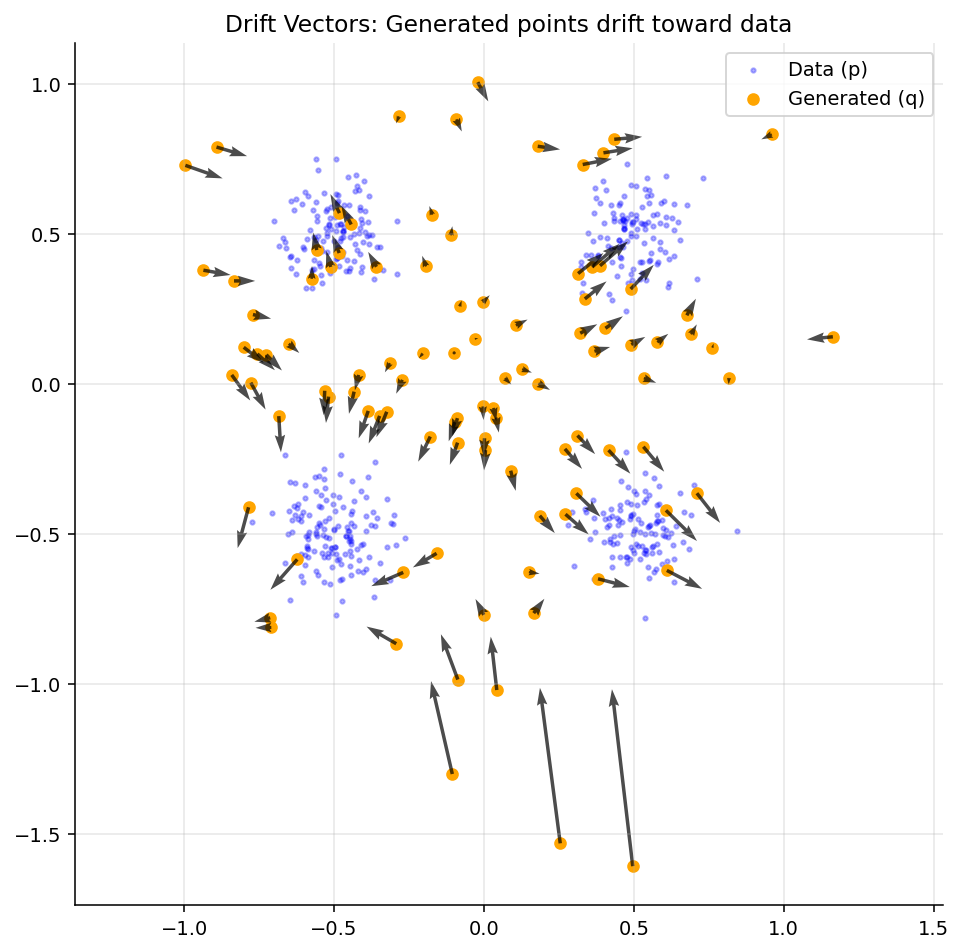

In [50]:
# Quick visualization of drift vectors, matching toy_mean_drift.py.
key = jax.random.PRNGKey(32)
gen_key, idx_key, noise_key = jax.random.split(key, 3)

# Random generated points (from Gaussian)
gen_test = jax.random.normal(gen_key, (100, 2), dtype=jnp.float32) * 0.5

# Target data: simple 4-mode Gaussian mixture
centers = jnp.array(
    [[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]],
    dtype=jnp.float32,
)
idx = jax.random.randint(idx_key, (500,), minval=0, maxval=4)
pos_test = centers[idx] + jax.random.normal(noise_key, (500, 2), dtype=jnp.float32) * 0.1

# Compute drift
# drift_test = compute_sinkhorn(gen_test, pos_test, temp=.2)

drift_test, drift_info = compute_drift(gen_test, pos_test, temp=.5)

gen_np = np.asarray(gen_test)
pos_np = np.asarray(pos_test)
drift_np = np.asarray(drift_test)

print("drift test shape", drift_test.shape)
print("drift info:", {k: v.item() for k, v in drift_info.items()})

plt.figure(figsize=(8, 8))
plt.scatter(pos_np[:, 0], pos_np[:, 1], s=5, alpha=0.3, c="blue", label="Data (p)")
plt.scatter(gen_np[:, 0], gen_np[:, 1], s=30, c="orange", label="Generated (q)")
plt.quiver(
    gen_np[:, 0],
    gen_np[:, 1],
    drift_np[:, 0],
    drift_np[:, 1],
    scale=3,
    color="black",
    alpha=0.7,
    width=0.004,
)
plt.legend()
plt.title("Drift Vectors: Generated points drift toward data")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()


In [51]:
def make_checkerboard(key, n=1024, cells=4, noise=0.025):
    key_idx, key_u, key_noise = jax.random.split(key, 3)
    active_cells = jnp.array(
        [[i, j] for i in range(cells) for j in range(cells) if (i + j) % 2 == 0],
        dtype=jnp.float32,
    )
    idx = jax.random.randint(key_idx, (n,), minval=0, maxval=active_cells.shape[0])
    unit = jax.random.uniform(key_u, (n, 2), dtype=jnp.float32)
    pts = (active_cells[idx] + unit) / cells
    pts = pts * 2.0 - 1.0
    pts = pts + noise * jax.random.normal(key_noise, (n, 2), dtype=jnp.float32)
    return pts


def make_swiss_roll(key, n=1024, noise=0.025):
    key_t, key_noise = jax.random.split(key)
    t = jax.random.uniform(key_t, (n,), minval=1.5 * jnp.pi, maxval=4.5 * jnp.pi)
    radius = t / (4.5 * jnp.pi)
    pts = jnp.stack([radius * jnp.cos(t), radius * jnp.sin(t)], axis=-1)
    pts = pts / jnp.max(jnp.abs(pts), axis=0, keepdims=True)
    pts = pts + noise * jax.random.normal(key_noise, (n, 2), dtype=jnp.float32)
    return pts.astype(jnp.float32)


In [52]:
def make_train_step(optimizer):
    @jax.jit
    def train_step(gen, fixed_pos, opt_state, temp):
        def objective(z):
            loss, info = drift_loss(
                query_actions=z,
                positive_actions=fixed_pos,
                temp=temp,
            )
            return loss, info

        (loss, info), grads = jax.value_and_grad(objective, has_aux=True)(gen)
        updates, opt_state = optimizer.update(grads, opt_state, gen)
        gen = optax.apply_updates(gen, updates)
        return gen, opt_state, loss, info

    return train_step


def run_dfp_toy(
    key,
    fixed_pos,
    n_gen=384,
    steps=800,
    lr=3e-2,
    temp=0.05,
    snapshot_steps=(0, 50, 200, 800, 1200, 1600),
):
    fixed_pos = fixed_pos[None, ...]
    gen = jax.random.uniform(key, (1, n_gen, fixed_pos.shape[-1]), minval=-1.25, maxval=1.25)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(gen)
    train_step = make_train_step(optimizer)

    snapshots = {0: np.asarray(gen[0])}
    losses = []
    infos = []

    for i in range(1, steps + 1):
        gen, opt_state, loss, info = train_step(gen, fixed_pos, opt_state, temp)
        losses.append(float(info["drift_norm"]))
        if i in snapshot_steps or i == steps:
            snapshots[i] = np.asarray(gen[0])
        if i == steps:
            infos.append({k: float(v) for k, v in info.items()})

    return np.asarray(gen[0]), snapshots, np.asarray(losses), infos[-1] if infos else {}


In [53]:
def plot_toy_run(title, target, snapshots, losses):
    steps = sorted(snapshots.keys())
    fig, axes = plt.subplots(1, len(steps) + 1, figsize=(3.0 * (len(steps) + 1), 3.0), constrained_layout=True)

    axes[0].scatter(np.asarray(target)[:, 0], np.asarray(target)[:, 1], s=2, c="#242424", alpha=0.45, linewidths=0)
    axes[0].set_title("target")
    axes[0].set_aspect("equal")
    axes[0].set_xlim(-1.35, 1.35)
    axes[0].set_ylim(-1.35, 1.35)

    for ax, step in zip(axes[1:], steps):
        pts = snapshots[step]
        ax.scatter(pts[:, 0], pts[:, 1], s=5, c="#2f80ed", alpha=0.78, linewidths=0)
        ax.set_title(f"step {step}")
        ax.set_aspect("equal")
        ax.set_xlim(-1.35, 1.35)
        ax.set_ylim(-1.35, 1.35)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(title, y=1.06, fontsize=12)
    plt.show()

    plt.figure(figsize=(4.5, 2.5))
    plt.plot(losses, color="#c44e52", linewidth=1.5)
    plt.yscale("log")
    plt.title(f"{title} loss")
    plt.xlabel("step")
    plt.ylabel("DFP drift loss")
    plt.tight_layout()
    plt.show()


In [56]:
key = jax.random.PRNGKey(0)
key, checker_key, swiss_key, checker_init_key, swiss_init_key = jax.random.split(key, 5)

checker = make_checkerboard(checker_key, n=1024, cells=4, noise=0.02)
swiss = make_swiss_roll(swiss_key, n=1024, noise=0.02)

checker_gen, checker_snapshots, checker_losses, checker_info = run_dfp_toy(
    checker_init_key,
    checker,
    n_gen=384,
    steps=2000,
    lr=3e-2,
    temp=.01,
    snapshot_steps=(0, 50, 200, 800),
)

swiss_gen, swiss_snapshots, swiss_losses, swiss_info = run_dfp_toy(
    swiss_init_key,
    swiss,
    n_gen=384,
    steps=2000,
    lr=3e-2,
    temp=.01,
    snapshot_steps=(0, 50, 200, 800),
)

checker_info, swiss_info


({'drift_norm': 0.00030419568065553904,
  'neg_dist_mean': 1.0220199823379517,
  'neg_mass_mean': 0.9999989867210388,
  'neg_weight_max': 0.99997878074646,
  'neg_weight_mean': 0.002604164183139801,
  'neg_weight_min': 0.0,
  'pos_dist_mean': 1.02006995677948,
  'pos_mass_mean': 0.9999999403953552,
  'pos_weight_max': 0.41671574115753174,
  'pos_weight_mean': 0.0009765622089616954,
  'pos_weight_min': 0.0,
  'temp': 0.009999999776482582},
 {'drift_norm': 9.999999747378752e-05,
  'neg_dist_mean': 0.9365568161010742,
  'neg_mass_mean': 0.9999989867210388,
  'neg_weight_max': 0.9883395433425903,
  'neg_weight_mean': 0.002604164183139801,
  'neg_weight_min': 0.0,
  'pos_dist_mean': 0.932722270488739,
  'pos_mass_mean': 0.9999999403953552,
  'pos_weight_max': 0.3949453830718994,
  'pos_weight_mean': 0.0009765622089616954,
  'pos_weight_min': 0.0,
  'temp': 0.009999999776482582})

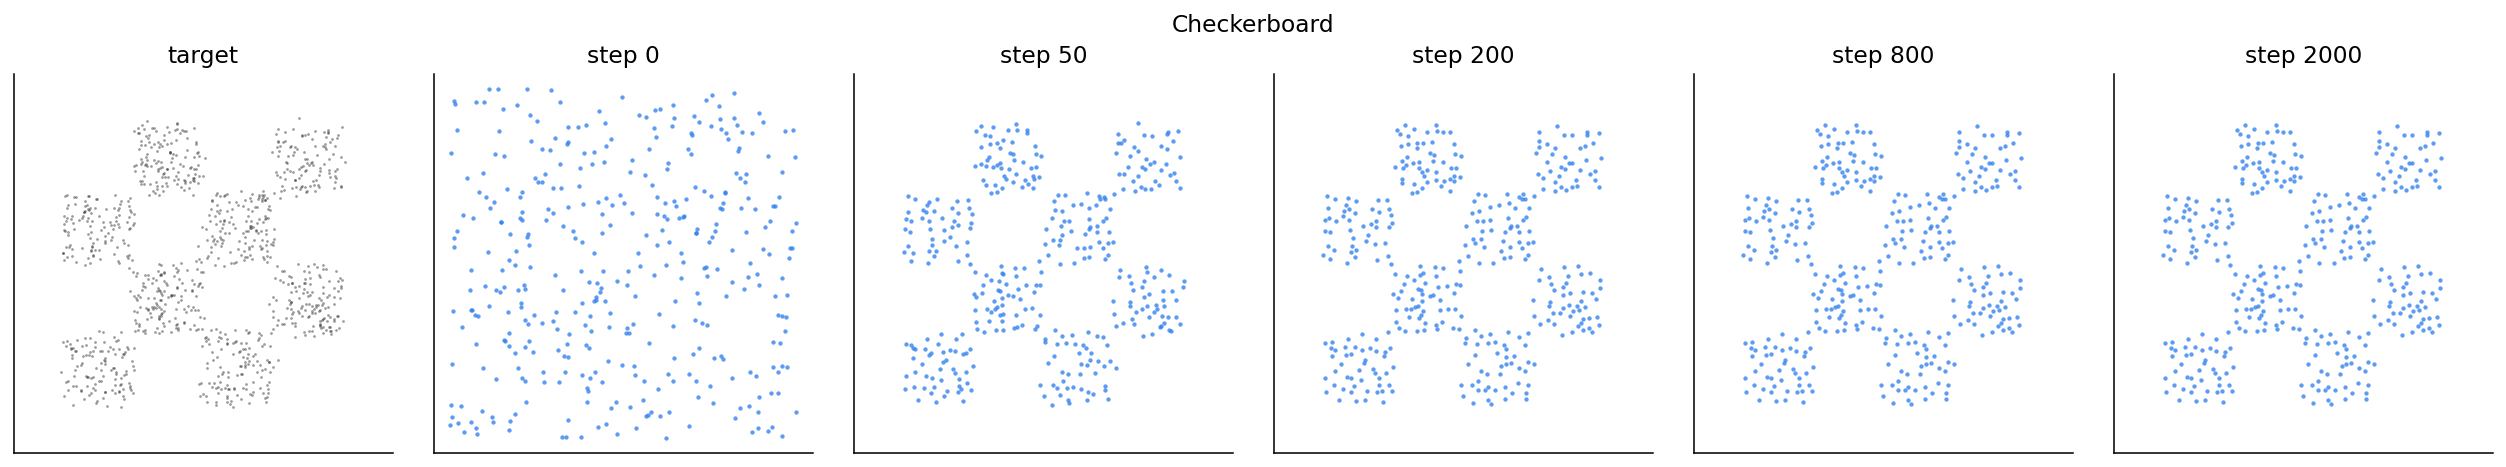

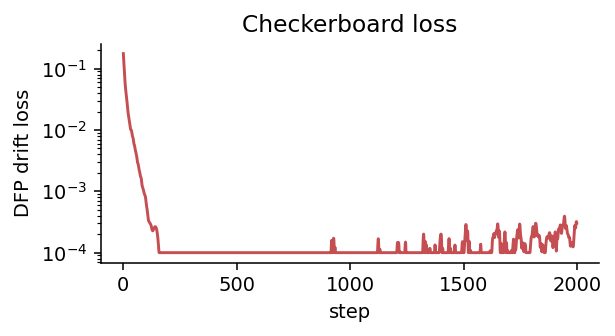

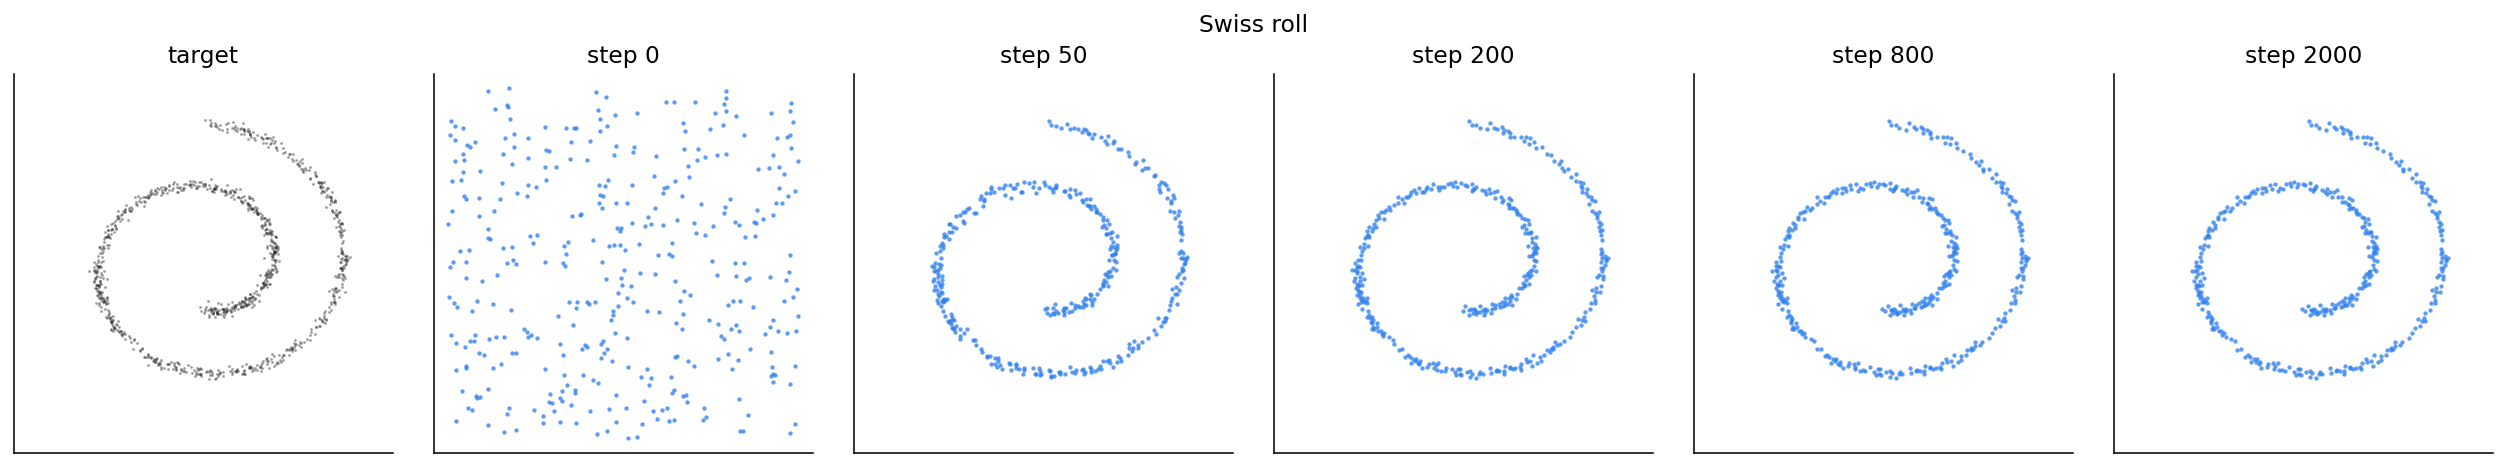

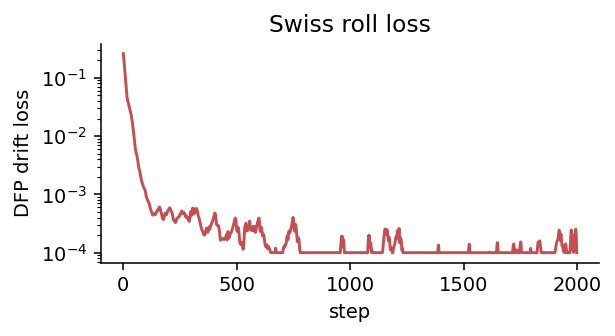

In [57]:
plot_toy_run("Checkerboard", checker, checker_snapshots, checker_losses)
plot_toy_run("Swiss roll", swiss, swiss_snapshots, swiss_losses)
